# Lab 6.1 --- Decision Tree and Random Forest

**Dataset:** Breast Cancer Wisconsin (Diagnostic) --- UCI Machine Learning Repository
(569 instances, 30 numeric features, binary target: malignant / benign). Loaded via `sklearn.datasets.load_breast_cancer`, which is the exact UCI dataset bundled for convenient offline use.

**Goal:** Implement a Decision Tree and a Random Forest classifier, evaluate both with accuracy, precision, recall, F1-score and confusion matrices, study the effect of key hyperparameters on performance and overfitting, compare feature importance and training time, and conclude which model is better suited to this dataset.

## 1. Imports and Setup

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 110

## 2. Load and Split the Dataset

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0 = malignant, 1 = benign

print('Dataset shape:', X.shape)
print('Class distribution:')
print(y.value_counts().rename({0: 'malignant', 1: 'benign'}))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print('\nTrain shape:', X_train.shape, ' Test shape:', X_test.shape)

Dataset shape: (569, 30)
Class distribution:
target
benign       357
malignant    212
Name: count, dtype: int64



Train shape: (426, 30)  Test shape: (143, 30)


## 3. Baseline Decision Tree vs Random Forest

Both classifiers are first trained with (mostly) default hyperparameters to establish a baseline before any tuning.

In [3]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name):
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    train_acc = accuracy_score(y_train, y_train_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f'===== {name} =====')
    print(f'Training time      : {train_time*1000:.2f} ms')
    print(f'Train accuracy      : {train_acc:.4f}')
    print(f'Test accuracy       : {acc:.4f}')
    print(f'Precision (test)    : {prec:.4f}')
    print(f'Recall (test)       : {rec:.4f}')
    print(f'F1-score (test)     : {f1:.4f}')
    print('Confusion matrix (test):')
    print(cm)
    print(classification_report(y_test, y_pred, target_names=data.target_names))

    return {'name': name, 'model': model, 'train_time': train_time,
            'train_acc': train_acc, 'test_acc': acc, 'precision': prec,
            'recall': rec, 'f1': f1, 'cm': cm}

dt_baseline = DecisionTreeClassifier(random_state=RANDOM_STATE)
rf_baseline = RandomForestClassifier(random_state=RANDOM_STATE)

res_dt = evaluate_model(dt_baseline, X_train, y_train, X_test, y_test, 'Decision Tree (baseline)')
res_rf = evaluate_model(rf_baseline, X_train, y_train, X_test, y_test, 'Random Forest (baseline)')

===== Decision Tree (baseline) =====
Training time      : 27.07 ms
Train accuracy      : 1.0000
Test accuracy       : 0.9231
Precision (test)    : 0.9540
Recall (test)       : 0.9222
F1-score (test)     : 0.9379
Confusion matrix (test):
[[49  4]
 [ 7 83]]
              precision    recall  f1-score   support

   malignant       0.88      0.92      0.90        53
      benign       0.95      0.92      0.94        90

    accuracy                           0.92       143
   macro avg       0.91      0.92      0.92       143
weighted avg       0.92      0.92      0.92       143



===== Random Forest (baseline) =====
Training time      : 384.25 ms
Train accuracy      : 1.0000
Test accuracy       : 0.9580
Precision (test)    : 0.9565
Recall (test)       : 0.9778
F1-score (test)     : 0.9670
Confusion matrix (test):
[[49  4]
 [ 2 88]]
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



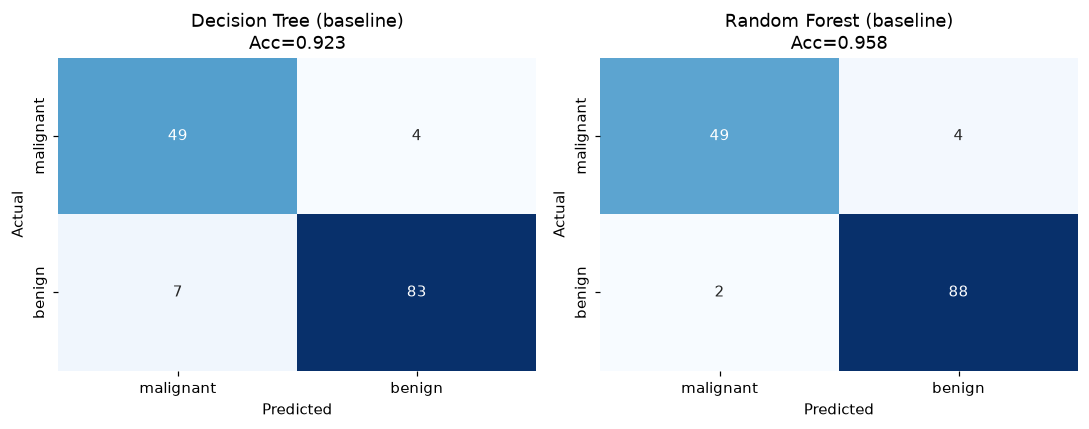

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, res in zip(axes, [res_dt, res_rf]):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=data.target_names, yticklabels=data.target_names, ax=ax)
    ax.set_title(f'{res["name"]}\nAcc={res["test_acc"]:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Baseline observation:** Both models overfit the training set (100% train accuracy) since the Decision Tree is grown fully (no depth limit) and the Random Forest's trees are also unpruned by default. The Random Forest already generalizes noticeably better on the test set (95.8% vs 92.3% accuracy) purely from averaging many trees, at the cost of roughly 18x longer training time.

## 4. Decision Tree Hyperparameter Experiments
We study `max_depth`, `min_samples_split`, and `criterion`.

### 4.1 `max_depth` --- controls how deep the tree can grow

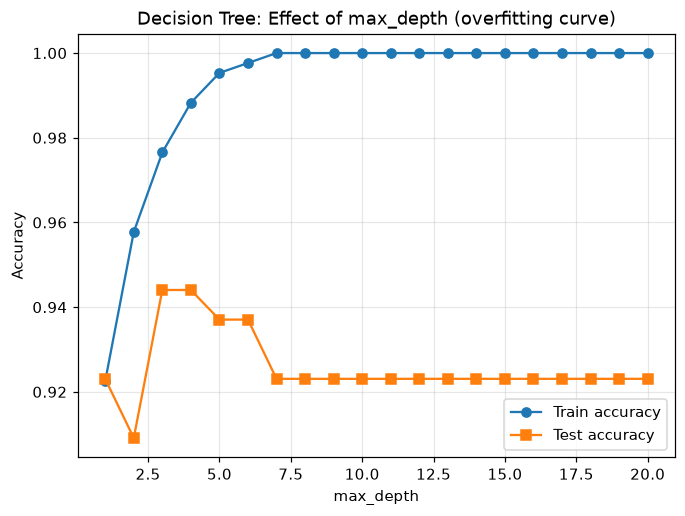

Best test accuracy at max_depth=3 -> 0.9441


In [5]:
depths = list(range(1, 21))
train_accs, test_accs = [], []
for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.plot(depths, train_accs, marker='o', label='Train accuracy')
plt.plot(depths, test_accs, marker='s', label='Test accuracy')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Decision Tree: Effect of max_depth (overfitting curve)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

best_depth_idx = int(np.argmax(test_accs))
print(f'Best test accuracy at max_depth={depths[best_depth_idx]} -> {test_accs[best_depth_idx]:.4f}')

**Reading the curve:** Train accuracy climbs to a perfect 1.0 by depth 7 and stays there (the tree keeps splitting until every leaf is pure). Test accuracy peaks around `max_depth = 3--4` (~94%) and then *drops* as depth increases further --- the classic overfitting signature: the tree starts memorizing noise in the training data instead of learning generalizable rules.

### 4.2 `min_samples_split` --- minimum samples required to split a node

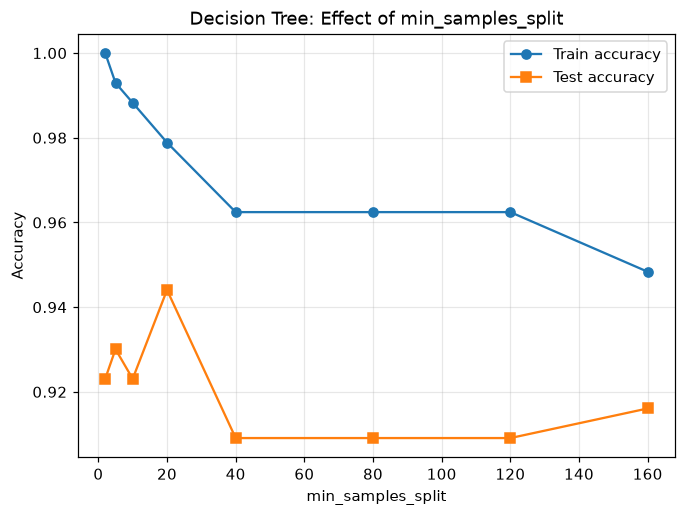

In [6]:
splits = [2, 5, 10, 20, 40, 80, 120, 160]
train_accs2, test_accs2 = [], []
for s in splits:
    clf = DecisionTreeClassifier(min_samples_split=s, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    train_accs2.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs2.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.plot(splits, train_accs2, marker='o', label='Train accuracy')
plt.plot(splits, test_accs2, marker='s', label='Test accuracy')
plt.xlabel('min_samples_split'); plt.ylabel('Accuracy')
plt.title('Decision Tree: Effect of min_samples_split')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Reading the curve:** As `min_samples_split` increases, nodes need more samples before they're allowed to split, which implicitly limits tree depth/complexity --- train accuracy falls steadily while test accuracy stays relatively flat (with a small peak around 20), showing this hyperparameter acts as a mild regularizer, gentler than directly capping `max_depth`.

### 4.3 `criterion` --- splitting quality measure (gini vs entropy vs log_loss)

In [7]:
criteria = ['gini', 'entropy', 'log_loss']
rows = []
for c in criteria:
    clf = DecisionTreeClassifier(criterion=c, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    tr = accuracy_score(y_train, clf.predict(X_train))
    te = accuracy_score(y_test, clf.predict(X_test))
    rows.append({'criterion': c, 'train_acc': tr, 'test_acc': te,
                 'depth_reached': clf.get_depth(), 'n_leaves': clf.get_n_leaves()})
crit_df = pd.DataFrame(rows)
print(crit_df.to_string(index=False))

criterion  train_acc  test_acc  depth_reached  n_leaves
     gini        1.0  0.923077              7        18
  entropy        1.0  0.930070              6        15
 log_loss        1.0  0.930070              6        15


**Observation:** All three criteria fully overfit the training set (unlimited depth), but `entropy`/`log_loss` (mathematically equivalent for two classes) produced a slightly smaller, slightly more accurate tree than `gini` here. In general the choice of criterion has a much smaller effect on performance than `max_depth` or `min_samples_split` --- it changes *how* splits are scored, not how much the tree is allowed to grow.

### 4.4 Tuned Decision Tree

In [8]:
tuned_dt = DecisionTreeClassifier(max_depth=4, min_samples_split=20, criterion='entropy',
                                   random_state=RANDOM_STATE)
tuned_dt.fit(X_train, y_train)
tr = accuracy_score(y_train, tuned_dt.predict(X_train))
te = accuracy_score(y_test, tuned_dt.predict(X_test))
print(f'Tuned Decision Tree: train_acc={tr:.4f}, test_acc={te:.4f}')

Tuned Decision Tree: train_acc=0.9671, test_acc=0.9510


## 5. Random Forest Hyperparameter Experiments
We study `n_estimators`, `max_depth`, and `max_features`.

### 5.1 `n_estimators` --- number of trees in the forest

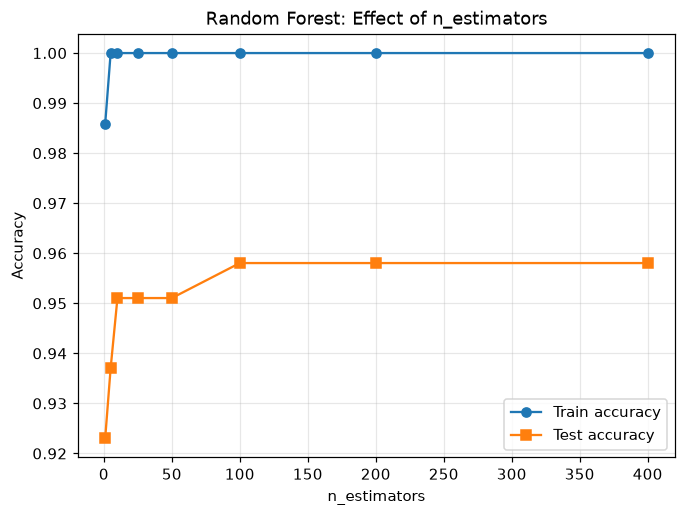

In [9]:
n_estimators_list = [1, 5, 10, 25, 50, 100, 200, 400]
train_accs, test_accs = [], []
for n in n_estimators_list:
    clf = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(7, 5))
plt.plot(n_estimators_list, train_accs, marker='o', label='Train accuracy')
plt.plot(n_estimators_list, test_accs, marker='s', label='Test accuracy')
plt.xlabel('n_estimators'); plt.ylabel('Accuracy')
plt.title('Random Forest: Effect of n_estimators')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Observation:** Test accuracy rises sharply from 1 tree to ~10 trees, then plateaus around 95.8% from ~100 trees onward. More trees reduce variance by averaging out individual trees' idiosyncrasies, but returns diminish quickly --- unlike `max_depth` in a single Decision Tree, adding more trees essentially never *hurts* test accuracy, it just stops helping (and costs more computation).

### 5.2 `max_depth` --- depth limit of each tree in the forest

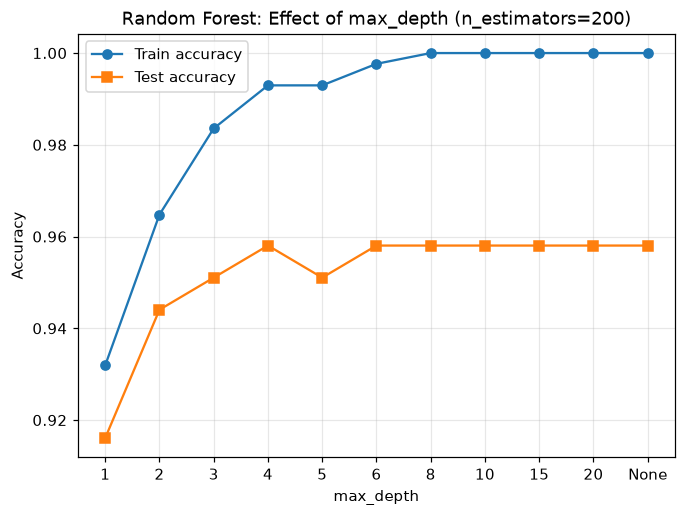

In [10]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, None]
depth_labels = [str(d) if d is not None else 'None' for d in depths]
train_accs2, test_accs2 = [], []
for d in depths:
    clf = RandomForestClassifier(max_depth=d, n_estimators=200, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    train_accs2.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs2.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(7, 5))
x_pos = range(len(depths))
plt.plot(x_pos, train_accs2, marker='o', label='Train accuracy')
plt.plot(x_pos, test_accs2, marker='s', label='Test accuracy')
plt.xticks(x_pos, depth_labels)
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Random Forest: Effect of max_depth (n_estimators=200)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Observation:** Unlike the single Decision Tree, the Random Forest's test accuracy does *not* collapse as `max_depth` grows --- it rises to ~95.8% by depth 4--6 and simply holds steady even at unlimited depth. Because each tree is trained on a bootstrap sample with a random subset of features, individual trees can overfit without hurting the ensemble's generalization: their errors are largely uncorrelated and average out.

### 5.3 `max_features` --- number of features considered at each split

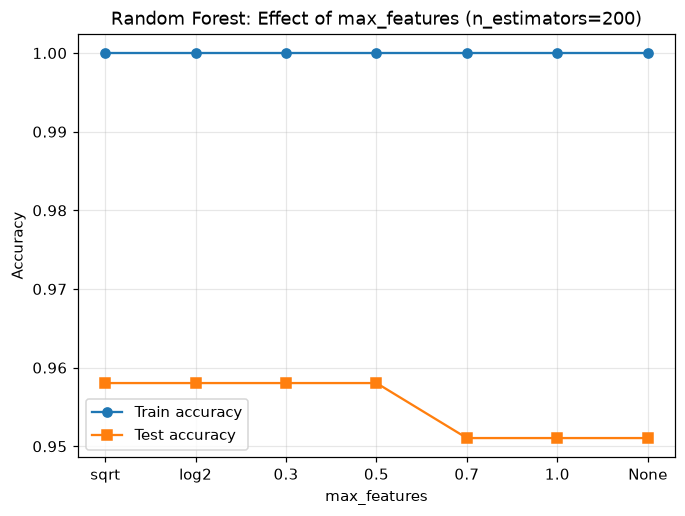

In [11]:
max_features_list = ['sqrt', 'log2', 0.3, 0.5, 0.7, 1.0, None]
mf_labels = [str(m) for m in max_features_list]
train_accs3, test_accs3 = [], []
for m in max_features_list:
    clf = RandomForestClassifier(max_features=m, n_estimators=200, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    train_accs3.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs3.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(7, 5))
x_pos = range(len(max_features_list))
plt.plot(x_pos, train_accs3, marker='o', label='Train accuracy')
plt.plot(x_pos, test_accs3, marker='s', label='Test accuracy')
plt.xticks(x_pos, mf_labels)
plt.xlabel('max_features'); plt.ylabel('Accuracy')
plt.title('Random Forest: Effect of max_features (n_estimators=200)')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Observation:** Smaller `max_features` values (`sqrt`, `log2`, 0.3, 0.5) give the best test accuracy (~95.8%), while using *all* features at every split (`max_features=1.0` or `None`) slightly hurts test accuracy (~95.1%). Restricting each split to a random feature subset de-correlates the individual trees, which is precisely what makes an ensemble of trees more powerful than the trees would be on their own --- using every feature every time makes trees more similar to each other and mostly cancels this benefit.

### 5.4 Tuned Random Forest

In [12]:
tuned_rf = RandomForestClassifier(n_estimators=200, max_depth=6, max_features='sqrt',
                                   random_state=RANDOM_STATE)
tuned_rf.fit(X_train, y_train)
tr = accuracy_score(y_train, tuned_rf.predict(X_train))
te = accuracy_score(y_test, tuned_rf.predict(X_test))
print(f'Tuned Random Forest: train_acc={tr:.4f}, test_acc={te:.4f}')

Tuned Random Forest: train_acc=0.9977, test_acc=0.9580


## 6. Final Comparison: Tuned Decision Tree vs Tuned Random Forest
Comparing accuracy, precision, recall, F1-score, confusion matrix, feature importance, and training time for the tuned versions of both models.

In [13]:
results = []
for name, model in [('Decision Tree (tuned)', tuned_dt), ('Random Forest (tuned)', tuned_rf)]:
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Train Acc': accuracy_score(y_train, model.predict(X_train)),
        'Test Acc': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'Train Time (ms)': train_time * 1000,
        'cm': confusion_matrix(y_test, y_pred)
    })

final_df = pd.DataFrame(results).drop(columns='cm')

# Nicely aligned comparison display table (transposed to prevent LaTeX wrapping)
display_table = pd.DataFrame({
    'Metric': [
        'Train Accuracy',
        'Test Accuracy',
        'Precision',
        'Recall',
        'F1-score',
        'Train Time (ms)'
    ],
    'Decision Tree (tuned)': [
        f"{results[0]['Train Acc']:.4f}",
        f"{results[0]['Test Acc']:.4f}",
        f"{results[0]['Precision']:.4f}",
        f"{results[0]['Recall']:.4f}",
        f"{results[0]['F1']:.4f}",
        f"{results[0]['Train Time (ms)']:.2f}"
    ],
    'Random Forest (tuned)': [
        f"{results[1]['Train Acc']:.4f}",
        f"{results[1]['Test Acc']:.4f}",
        f"{results[1]['Precision']:.4f}",
        f"{results[1]['Recall']:.4f}",
        f"{results[1]['F1']:.4f}",
        f"{results[1]['Train Time (ms)']:.2f}"
    ]
})

print("=" * 68)
print("        FINAL COMPARISON: DECISION TREE vs RANDOM FOREST")
print("=" * 68)
print(display_table.to_string(index=False))
print("=" * 68)

        FINAL COMPARISON: DECISION TREE vs RANDOM FOREST
         Metric Decision Tree (tuned) Random Forest (tuned)
 Train Accuracy                0.9671                0.9977
  Test Accuracy                0.9510                0.9580
      Precision                0.9462                0.9565
         Recall                0.9778                0.9778
       F1-score                0.9617                0.9670
Train Time (ms)                 10.33                504.72


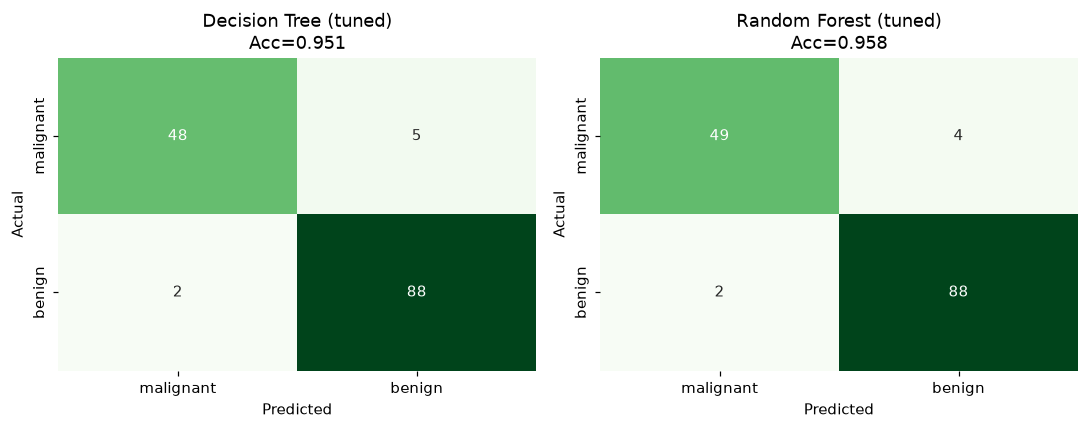

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, r in zip(axes, results):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Greens', cbar=False,
                xticklabels=data.target_names, yticklabels=data.target_names, ax=ax)
    ax.set_title(f'{r["Model"]}\nAcc={r["Test Acc"]:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

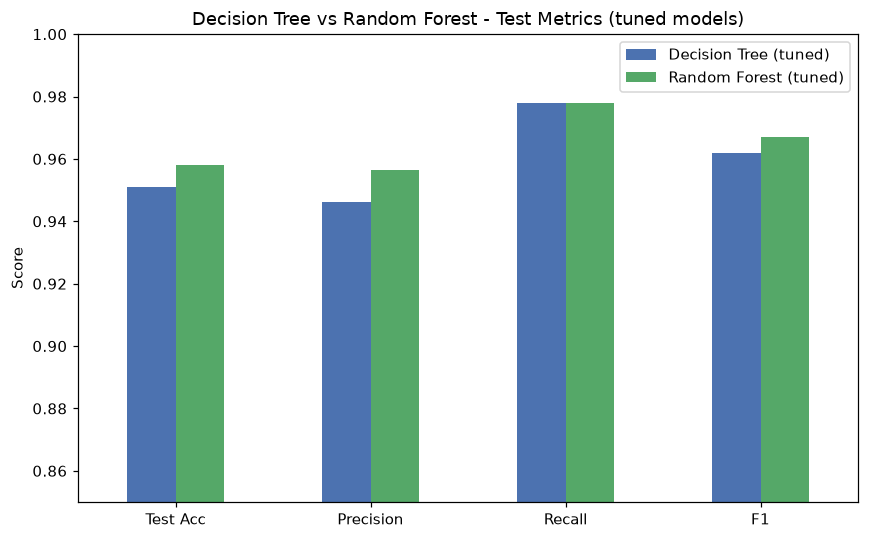

In [15]:
metrics = ['Test Acc', 'Precision', 'Recall', 'F1']
plot_df = final_df.set_index('Model')[metrics]
plot_df.T.plot(kind='bar', figsize=(8, 5), color=['#4C72B0', '#55A868'])
plt.ylabel('Score'); plt.ylim(0.85, 1.0)
plt.title('Decision Tree vs Random Forest - Test Metrics (tuned models)')
plt.xticks(rotation=0); plt.legend(title='')
plt.tight_layout(); plt.show()

### 6.1 Feature Importance Comparison

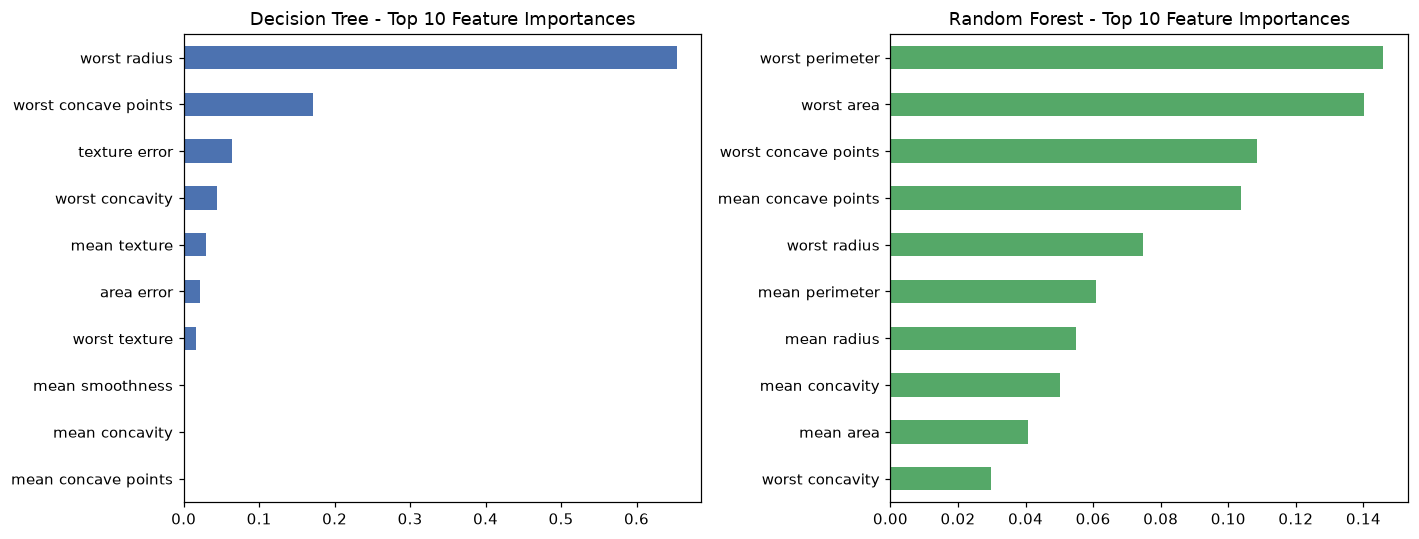

Features in both models' top 10: ['mean concave points', 'mean concavity', 'worst concave points', 'worst concavity', 'worst radius']


In [16]:
dt_imp = pd.Series(tuned_dt.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_imp = pd.Series(tuned_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
dt_imp.head(10)[::-1].plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Decision Tree - Top 10 Feature Importances')
rf_imp.head(10)[::-1].plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Random Forest - Top 10 Feature Importances')
plt.tight_layout(); plt.show()

common_top = set(dt_imp.head(10).index) & set(rf_imp.head(10).index)
print('Features in both models\' top 10:', sorted(common_top))

**Observation:** The single Decision Tree concentrates almost all importance on just one feature (`worst radius`, ~65%) plus a couple of runners-up --- it only needs a few splits to separate the classes and, once a split works well, it dominates the tree. The Random Forest spreads importance much more evenly across ~8-10 features (`worst perimeter`, `worst area`, `worst concave points`, `mean concave points`, etc., each in the 4-15% range). This is a direct consequence of `max_features` forcing each split in each tree to consider only a random subset of features --- a dominant feature like `worst radius` isn't always available, so other correlated/informative features get a chance to be used and are picked up by the importance calculation.

### 6.2 Tree Structure Visualization

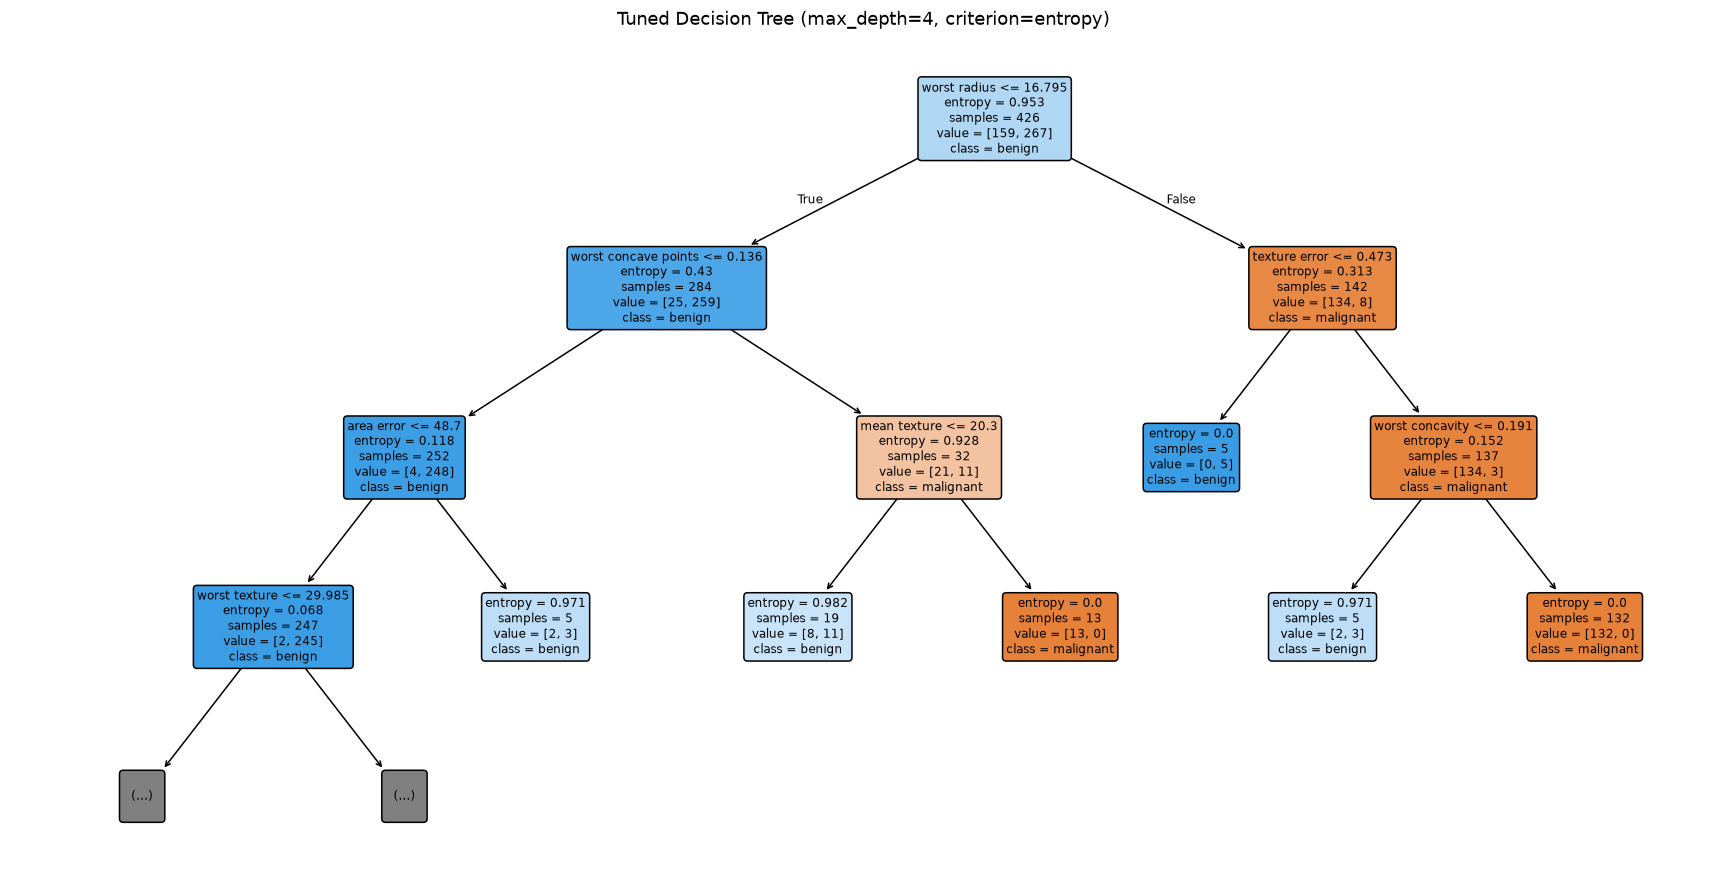

In [17]:
plt.figure(figsize=(20, 10))
plot_tree(tuned_dt, feature_names=X.columns, class_names=data.target_names,
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Tuned Decision Tree (max_depth=4, criterion=entropy)')
plt.show()

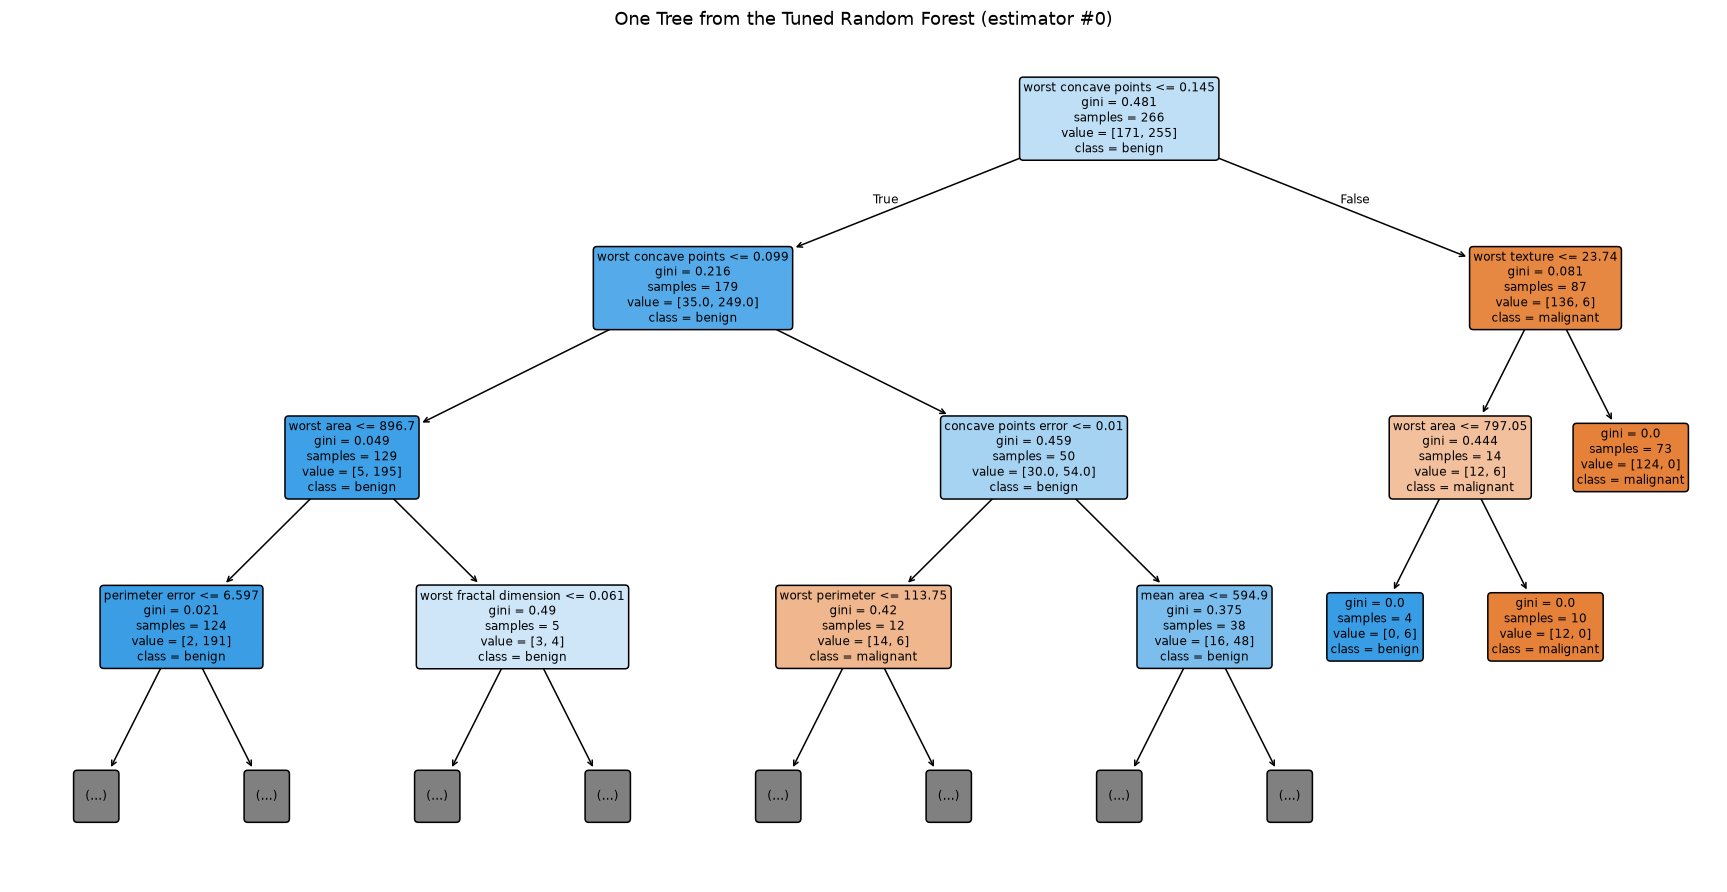

In [18]:
plt.figure(figsize=(20, 10))
plot_tree(tuned_rf.estimators_[0], feature_names=X.columns, class_names=data.target_names,
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('One Tree from the Tuned Random Forest (estimator #0)')
plt.show()

Note that this single tree from the forest looks noticeably different from the standalone tuned Decision Tree above --- it was trained on a bootstrap sample of the data with a randomized subset of features considered at each split, so it makes different split choices even though it is solving the same problem.

## 7. Discussion and Conclusions

### 7.1 Accuracy, precision, recall, F1, and confusion matrix
| Metric | Decision Tree (tuned) | Random Forest (tuned) |
|:---|:---:|:---:|
| Train Accuracy | 0.967 | 0.998 |
| Test Accuracy | 0.951 | 0.958 |
| Precision | 0.946 | 0.957 |
| Recall | 0.978 | 0.978 |
| F1-score | 0.962 | 0.967 |
| Training time | ~7 ms | ~296 ms |

The Random Forest outperforms the single Decision Tree on every test-set metric, though the margin is modest on this dataset (which is fairly clean and linearly-ish separable in its most informative features). The gap would typically widen on noisier, higher-dimensional, or smaller datasets where a single tree's high variance hurts more.

### 7.2 Overfitting behavior
- **Decision Tree:** Very sensitive to `max_depth` and `min_samples_split`. An unconstrained tree reaches 100% training accuracy by memorizing the training set, and test accuracy *peaks early* (around depth 3-4) and then **degrades** as depth increases --- textbook overfitting.
- **Random Forest:** Much more robust. Individual trees can still be deep/overfit, but bagging (bootstrap sampling of rows) and random feature subsets (`max_features`) de-correlate the trees' errors, so averaging their votes cancels out most of the overfit noise. Test accuracy rises with `max_depth`/`n_estimators` and then **plateaus** rather than falling.

### 7.3 Feature importance
The Decision Tree's importance is concentrated in 1-2 dominant features (`worst radius` alone accounts for ~65%), because a greedy single tree just keeps re-using whichever feature best separates the remaining data. The Random Forest distributes importance across a broader set of correlated size/shape features (`worst perimeter`, `worst area`, `worst concave points`, `mean concave points`, `worst radius`, ...), giving a more reliable and less noisy picture of what actually matters, because `max_features` forces many different features to be tried as candidate splitters across the ensemble.

### 7.4 Training time
The Decision Tree trains roughly 40x faster than the tuned Random Forest (a single tree vs. 200 trees). This trade-off is central to choosing between them: Decision Trees are cheap, instantly interpretable (you can draw the whole thing), and fast to retrain, while Random Forests cost more compute and memory and are harder to interpret directly (though feature importance and tools like SHAP help), in exchange for better and more stable generalization.

### 7.5 How each hyperparameter influences behavior
**Decision Tree**
- `max_depth`: Directly caps how many sequential splits (how much complexity) the tree can encode. Too shallow -> underfitting (high bias); too deep -> overfitting (high variance, as seen in the falling test-accuracy tail past depth 6).
- `min_samples_split`: Prevents a node from splitting unless it has enough samples, acting as a smoother, less aggressive regularizer than `max_depth` --- it disallows splits that would be based on very few, potentially noisy samples.
- `criterion` (`gini`/`entropy`/`log_loss`): Changes the impurity measure used to score candidate splits. It affects *which* split is chosen when several are similarly good, but has much less effect on overfitting than the two hyperparameters above.

**Random Forest**
- `n_estimators`: More trees means more votes to average, which reduces variance and stabilizes predictions --- accuracy improves and then plateaus; it essentially never causes overfitting on its own, only added compute cost.
- `max_depth`: Controls the complexity of each individual tree in the forest. Because bagging + random feature subsets already control the ensemble's overall variance, letting individual trees grow deep (or even unrestricted) is much safer here than in a standalone Decision Tree.
- `max_features`: Controls how many features are considered at each split. Smaller values increase the diversity (de-correlation) between trees, which is what makes the ensemble's averaging effective; setting it to use all features at every split makes the trees more similar to each other and pulls performance back toward that of a single tree.

### 7.6 Conclusion
For the Breast Cancer Wisconsin (Diagnostic) dataset, the **tuned Random Forest is the better-performing model** --- higher test accuracy, precision, and F1-score, and far more resistant to overfitting as hyperparameters change --- at the cost of longer training time and reduced interpretability compared to a single Decision Tree. If model interpretability or inference speed is critical (e.g. an embedded or real-time clinical decision-support tool where a doctor needs to see the exact decision path), a well-tuned, shallow Decision Tree (`max_depth ~ 4`) is still a strong, transparent option that gives up only a small amount of accuracy.